## **TASK 1: MCP Neurons**

### **AND Gate**

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

### **OR Gate**

In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

## **TASK 2: PERCEPTRON**

### **Load Dataset**

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/AI/mnist_0_and_1.csv")

X = df.drop(columns=["label"]).values
y = df["label"].values

print(X.shape)
print(y.shape)

(12665, 784)
(12665,)


### **Initialize Weights**

In [ ]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

### **Decision Function**

In [ ]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

### **Train Perceptron**

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for _ in range(epochs):
        for i in range(len(X)):

            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            error = y[i] - y_pred

            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error

    predictions = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy = np.sum(predictions == y)

    return weights, bias, accuracy

### **Train Model**

In [ ]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Accuracy:", accuracy)

Accuracy: 12665


### **Misclassified Images**

In [ ]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != y)[0]

## **Task 3: Perceptron (3 vs 5)**

### **Load Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/AI/mnist_3_and_5.csv")

# Split features and labels
X = df.drop(columns=["label"]).values
y = df["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2741, 784)
y shape: (2741,)


### **Visualize Data**

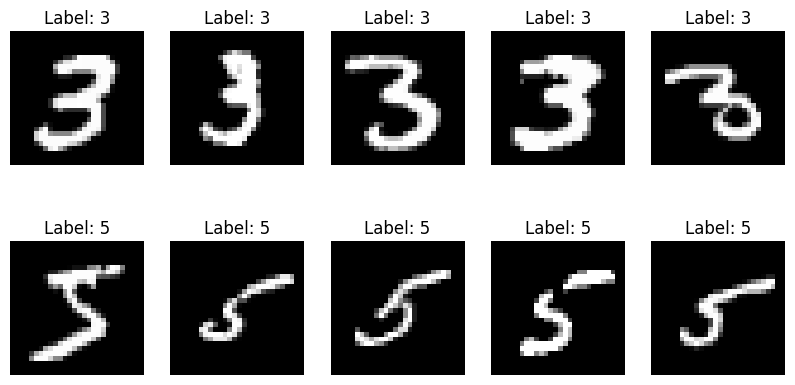

In [ ]:
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28,28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28,28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.show()

### **Convert Labels**

In [ ]:
y = np.where(y == 3, 0, 1)   # 3 → 0, 5 → 1

### **Initialize Weights**

In [ ]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

### **Decision Function**

In [ ]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    return np.where(predictions >= 0, 1, 0)

### **Train Perceptron**

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for _ in range(epochs):
        for i in range(len(X)):

            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            error = y[i] - y_pred

            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error

    predictions = decision_function(X, weights, bias)
    accuracy = np.mean(predictions == y)

    return weights, bias, accuracy

**Train Model**

In [ ]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Final Accuracy: 0.986866107260124


**Misclassified Images**

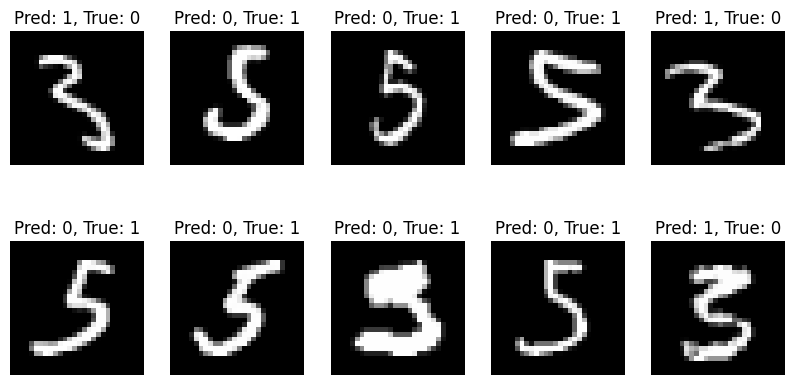

In [ ]:
predictions = decision_function(X, weights, bias)

misclassified_idx = np.where(predictions != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10,5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28,28), cmap="gray")
        ax.set_title(f"Pred: {predictions[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")